
Loads a single run directory from `experiments/carla_scenarios/` and plots:
1. brake per agent (overlay) with phase bands
2. throttle per agent (overlay)
3. steer per agent (overlay)
4. leader vs follower speed (ground truth)
5. distance leader↔follower (ground truth)

In [1]:
import json
import os
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd

SCRIPT_DIR = os.path.abspath(os.path.join(os.getcwd()))
REPO_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..', '..'))
RUNS_DIR = os.path.join(REPO_ROOT, 'experiments', 'carla_scenarios')

runs = sorted(
    [d for d in glob(os.path.join(RUNS_DIR, '*_*')) if os.path.isdir(d)],
    key=os.path.getmtime,
)
RUN_DIR = runs[-1]
print('Analyzing:', RUN_DIR)

Analyzing: /Users/paolodeidda/Documents/UNI/Master/Tesi/adversarial-patch-vehicle/experiments/carla_scenarios/none_20260416_212205


In [2]:
with open(os.path.join(RUN_DIR, 'summary.json')) as f:
    summary = json.load(f)
tele = pd.read_csv(os.path.join(RUN_DIR, 'telemetry.csv'))
agent_files = sorted(glob(os.path.join(RUN_DIR, 'agent_*.csv')))
agents = {os.path.basename(p)[len('agent_'):-len('.csv')]: pd.read_csv(p) for p in agent_files}

CRUISE_END = summary['cruise_end_tick'] * 0.05
BRAKE_START = summary['brake_start_tick'] * 0.05
SIM_END = summary['sim_duration_s']

print(f"condition={summary['condition']}  agents={list(agents)}")
print(f"phases: cruise [0, {CRUISE_END}s]  patch [{CRUISE_END}, {BRAKE_START}s]  brake [{BRAKE_START}, {SIM_END}s]")
print(f"collisions={summary['total_collisions']}  min_dist={summary['min_distance_m']}m")
for name, df in agents.items():
    print(f"  {name}: {len(df)} rows")

condition=none  agents=['simlingo_simlingo', 'tfv4_l6_0', 'tfv6_visiononly']
phases: cruise [0, 5.0s]  patch [5.0, 10.0s]  brake [10.0, 15.0s]
collisions=68  min_dist=4.694m
  simlingo_simlingo: 300 rows
  tfv4_l6_0: 300 rows
  tfv6_visiononly: 300 rows


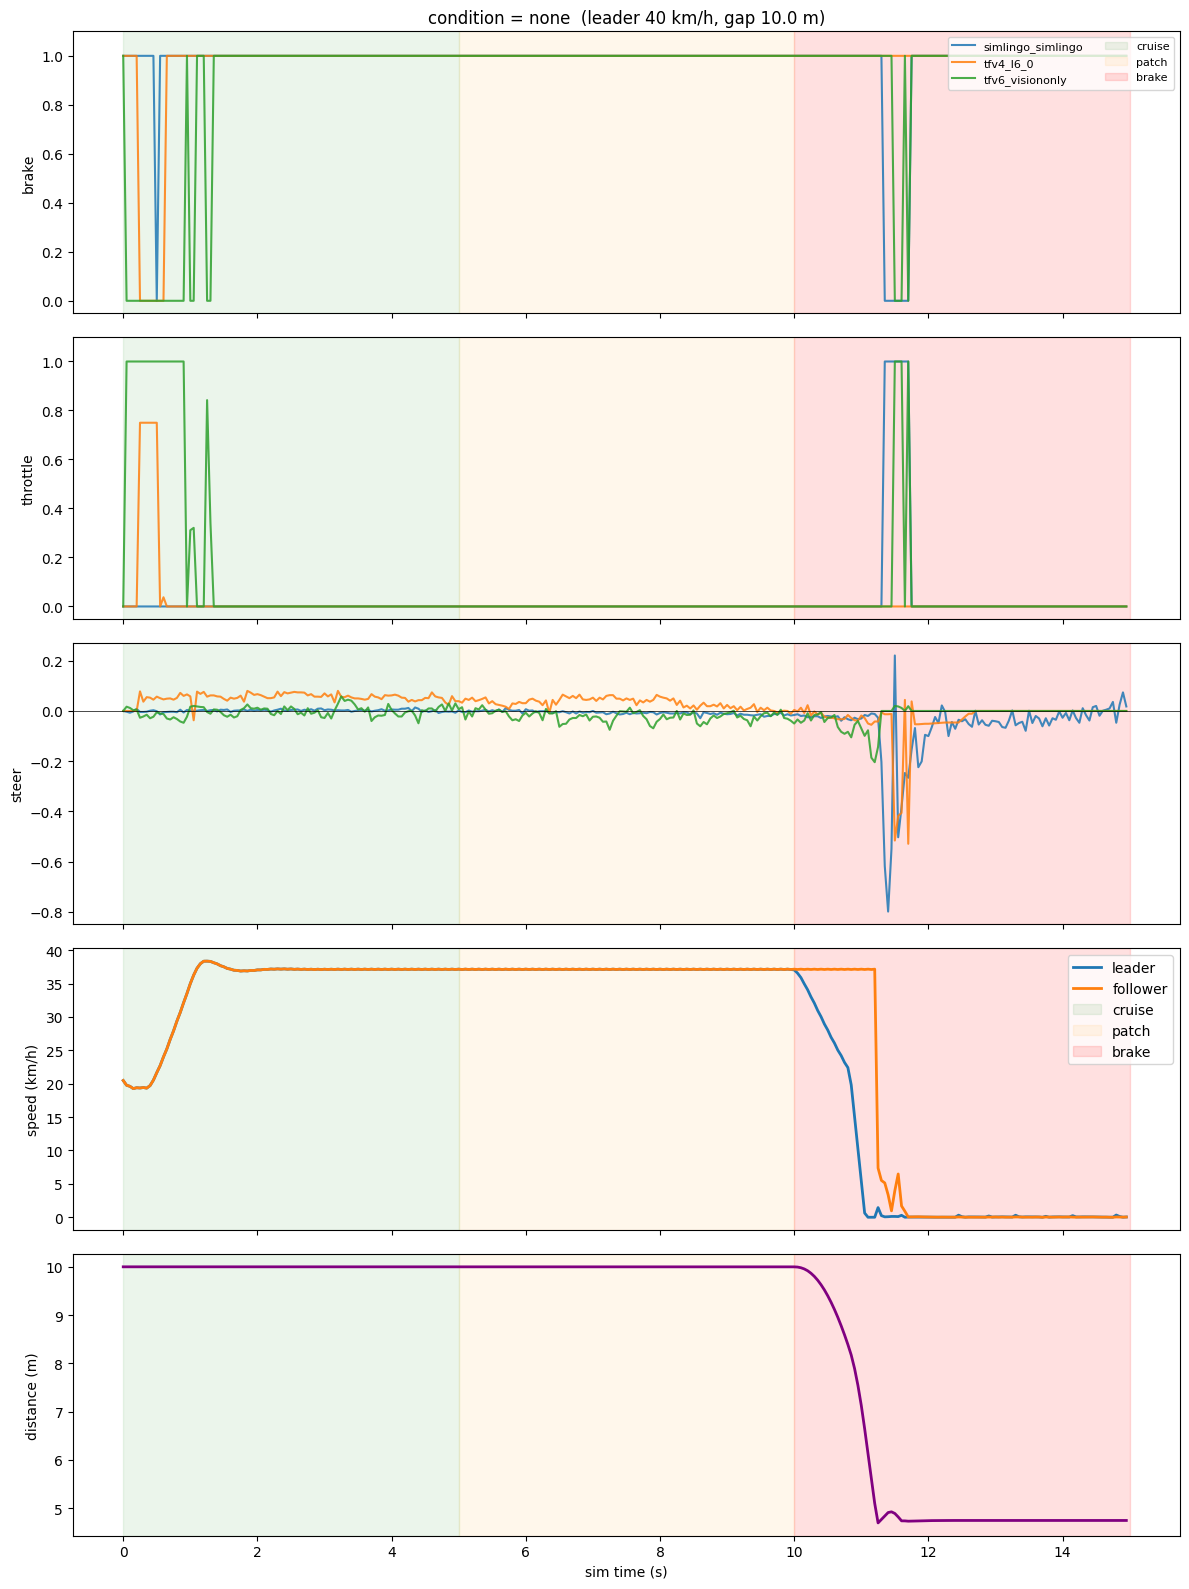

In [3]:
def shade_phases(ax):
    ax.axvspan(0, CRUISE_END, alpha=0.08, color='green', label='cruise')
    ax.axvspan(CRUISE_END, BRAKE_START, alpha=0.08, color='orange', label='patch')
    ax.axvspan(BRAKE_START, SIM_END, alpha=0.12, color='red', label='brake')

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

# 1) brake
for name, df in agents.items():
    axes[0].plot(df['sim_time_s'], df['brake'], label=name, alpha=0.85)
shade_phases(axes[0])
axes[0].set_ylabel('brake')
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(loc='upper right', ncol=2, fontsize=8)
axes[0].set_title(f"condition = {summary['condition']}  (leader {summary['leader_speed_kmh']} km/h, gap {summary['initial_gap_m']} m)")

# 2) throttle
for name, df in agents.items():
    axes[1].plot(df['sim_time_s'], df['throttle'], label=name, alpha=0.85)
shade_phases(axes[1])
axes[1].set_ylabel('throttle')
axes[1].set_ylim(-0.05, 1.1)

# 3) steer
for name, df in agents.items():
    axes[2].plot(df['sim_time_s'], df['steer'], label=name, alpha=0.85)
shade_phases(axes[2])
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_ylabel('steer')

# 4) speeds (ground truth)
axes[3].plot(tele['sim_time_s'], tele['leader_speed_kmh'], label='leader', lw=2)
axes[3].plot(tele['sim_time_s'], tele['follower_speed_kmh'], label='follower', lw=2)
shade_phases(axes[3])
axes[3].set_ylabel('speed (km/h)')
axes[3].legend(loc='upper right')

# 5) distance
axes[4].plot(tele['sim_time_s'], tele['distance_m'], color='purple', lw=2)
shade_phases(axes[4])
axes[4].set_ylabel('distance (m)')
axes[4].set_xlabel('sim time (s)')

plt.tight_layout()
plt.show()

## Aggregate stats per agent

In [4]:
rows = []
for name, df in agents.items():
    rows.append({
        'agent': name,
        'mean_throttle': df['throttle'].mean(),
        'mean_brake': df['brake'].mean(),
        'mean_abs_steer': df['steer'].abs().mean(),
        'ticks_brake>0.5': int((df['brake'] > 0.5).sum()),
        'ticks_throttle>0.1': int((df['throttle'] > 0.1).sum()),
    })
pd.DataFrame(rows).round(3)

,agent,mean_throttle,mean_brake,mean_abs_steer,ticks_brake>0.5,ticks_throttle>0.1
0,simlingo_simlingo,0.027,0.970,0.029,291,8
1,tfv4_l6_0,0.015,0.973,0.040,292,6
2,tfv6_visiononly,0.079,0.913,0.019,274,26


## Compare conditions (none / raw / camouflaged)

Once all 3 runs exist, set `RUN_BY_CONDITION` to explicit paths and re-run the cell.

In [5]:
# RUN_BY_CONDITION = {
#     'none': '/path/to/none_run',
#     'raw': '/path/to/raw_run',
#     'camouflaged': '/path/to/camouflaged_run',
# }

# Auto-pick latest per condition:
RUN_BY_CONDITION = {}
for cond in ('none', 'raw', 'camouflaged'):
    candidates = sorted(
        glob(os.path.join(RUNS_DIR, f'{cond}_*')),
        key=os.path.getmtime,
    )
    if candidates:
        RUN_BY_CONDITION[cond] = candidates[-1]

print('Using:')
for c, p in RUN_BY_CONDITION.items():
    print(f'  {c:12s} → {os.path.basename(p)}')

if len(RUN_BY_CONDITION) >= 2:
    agent_names = sorted({os.path.basename(p)[len('agent_'):-len('.csv')]
                          for run in RUN_BY_CONDITION.values()
                          for p in glob(os.path.join(run, 'agent_*.csv'))})
    fig, axes = plt.subplots(len(agent_names), 1, figsize=(12, 3.5 * len(agent_names)), sharex=True)
    if len(agent_names) == 1:
        axes = [axes]
    for ax, agent in zip(axes, agent_names):
        for cond, run in RUN_BY_CONDITION.items():
            fp = os.path.join(run, f'agent_{agent}.csv')
            if os.path.exists(fp):
                df = pd.read_csv(fp)
                ax.plot(df['sim_time_s'], df['brake'], label=cond, alpha=0.85)
        ax.set_ylabel(f'{agent}\nbrake')
        ax.set_ylim(-0.05, 1.1)
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('sim time (s)')
    fig.suptitle('Brake signal per agent, across conditions')
    plt.tight_layout()
    plt.show()

Using:
  none         → none_20260416_212205
